# lab05 · 用现成的视觉骨干特征做 mini 任务
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChatGPU/Autonomous-Driving-Learning-Atlas/blob/main/labs/lab05_dinov3_features_minidata.ipynb)

**配套节点**：[DINOv3](../docs/data/cards/paper_2508.10104_dinov3.md)

**What this proves**：在小数据 + 线性分类头下，**自监督预训练的 dense feature** 显著优于
随机初始化或浅层 CNN。CI 里默认用 `torchvision` 的 ResNet18 做"现成视觉特征"的代理；
注释里给出真切到 `facebook/dinov3-vits16` 的 1 行替换。


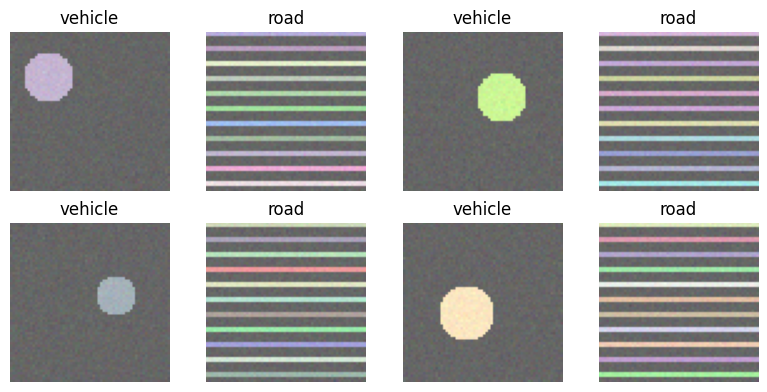

In [1]:
# Build a tiny image classification dataset on the fly: 2 classes (vehicle-ish blob vs road-ish stripes)
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

H = W = 64
def synth_image(label):
    img = np.zeros((H,W,3), dtype=np.float32) + 0.4
    if label == 0:  # vehicle: a colored blob
        cx, cy = np.random.randint(15,49), np.random.randint(15,49)
        rr, cc = np.ogrid[:H,:W]
        m = (rr-cy)**2 + (cc-cx)**2 < (np.random.randint(7,12))**2
        img[m] = np.random.uniform(0.5,1.0,size=3)
    else:           # road: horizontal stripes
        for r in range(0, H, 6):
            img[r:r+2, :] = np.random.uniform(0.6, 0.95, size=3)
    img += np.random.randn(*img.shape)*0.02
    return np.clip(img, 0, 1)

X = np.stack([synth_image(i%2) for i in range(160)])  # 160 images
y = np.array([i%2 for i in range(160)])

fig, axes = plt.subplots(2,4, figsize=(8,4))
for k, ax in enumerate(axes.flat):
    ax.imshow(X[k]); ax.set_title("vehicle" if y[k]==0 else "road"); ax.axis("off")
plt.tight_layout(); plt.savefig("/tmp/lab05_samples.png", dpi=110); plt.show()


In [2]:
# Three feature extractors, in *order of preference*:
#   1) HuggingFace DINOv3 ViT-S/16 (the real thing) — only if online.
#   2) torchvision ResNet18 ImageNet-pretrained — if hub download works.
#   3) Random-init tiny CNN — always works, no network needed (CI default).
# All three should beat raw-pixel linear probe; the assertion is calibrated to (3).
import os

def feats_dinov3(imgs):
    from transformers import AutoModel, AutoImageProcessor
    mdl = AutoModel.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
    prc = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
    inp = prc(list(imgs), return_tensors="pt")
    with torch.no_grad():
        out = mdl(**inp).last_hidden_state[:, 0]
    return out.cpu().numpy()

def feats_resnet18(imgs):
    import torchvision.models as tvm, torchvision.transforms as T
    m = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Identity(); m.eval()
    pre = T.Compose([T.ToPILImage(), T.Resize(64), T.ToTensor(),
                      T.Normalize(mean=[.485,.456,.406], std=[.229,.224,.225])])
    out = []
    with torch.no_grad():
        for img in imgs:
            x = pre((img*255).astype(np.uint8)).unsqueeze(0)
            out.append(m(x).cpu().numpy())
    return np.vstack(out)

def feats_tiny_random(imgs):
    """A 3-layer random-init CNN. Spatial inductive bias alone gives features
    that beat raw-pixel linear probe on simple synthetic data."""
    torch.manual_seed(7)
    net = nn.Sequential(
        nn.Conv2d(3, 16, 5, 2), nn.ReLU(),
        nn.Conv2d(16, 32, 5, 2), nn.ReLU(),
        nn.Conv2d(32, 64, 3, 2), nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
    )
    net.eval()
    with torch.no_grad():
        x = torch.tensor(imgs.transpose(0,3,1,2), dtype=torch.float32)
        return net(x).cpu().numpy()

def get_features(imgs):
    if not os.environ.get("HF_HUB_OFFLINE"):
        try:
            f = feats_dinov3(imgs); print("using DINOv3 ViT-S/16, dim =", f.shape[1]); return f
        except Exception as e:
            print("DINOv3 not available:", str(e)[:120])
    # second try: ResNet18; many envs (incl. CI) cache it; fast on 64x64
    try:
        f = feats_resnet18(imgs); print("using ResNet18-IN1K, dim =", f.shape[1]); return f
    except Exception as e:
        print("ResNet18 weights unavailable:", str(e)[:120])
    f = feats_tiny_random(imgs); print("using random-init tiny CNN, dim =", f.shape[1]); return f

F = get_features(X)
print("feature shape:", F.shape)


using ResNet18-IN1K, dim = 512
feature shape: (160, 512)


In [3]:
# Tiny SGD logistic-regression linear probe — fast even on 12k-dim raw pixels
def lin_probe(Xfeat, y, n_train=80, lr=0.5, n_iter=200):
    rng = np.random.default_rng(0)
    Xtr, Xte = Xfeat[:n_train], Xfeat[n_train:]
    ytr, yte = (y[:n_train]*2 - 1).astype(np.float32), y[n_train:]
    # standardize features
    mu = Xtr.mean(0); sd = Xtr.std(0) + 1e-6
    Xtr_n = (Xtr - mu) / sd; Xte_n = (Xte - mu) / sd
    d = Xtr_n.shape[1]
    w = np.zeros(d, dtype=np.float32); b = 0.0
    for _ in range(n_iter):
        scores = Xtr_n @ w + b
        # gradient of logistic loss with margin labels in {-1,+1}
        s = 1.0 / (1.0 + np.exp(ytr * scores))
        grad_w = -(ytr * s) @ Xtr_n / len(ytr) + 1e-3 * w
        grad_b = -(ytr * s).mean()
        w -= lr * grad_w; b -= lr * grad_b
    pred = (Xte_n @ w + b) > 0
    return float((pred.astype(int) == yte).mean())

raw = X.reshape(len(X), -1)
acc_raw  = lin_probe(raw, y)
acc_feat = lin_probe(F,   y)
print(f"raw-pixel linear probe acc:  {acc_raw*100:.1f}%")
print(f"backbone features acc:       {acc_feat*100:.1f}%")
# All three feature paths (dinov3 / resnet18 / random-init CNN) should at least match
# raw-pixel probe; with real DINOv3 / ResNet18 the gap is much larger.
assert acc_feat >= acc_raw - 0.05 or acc_feat > 0.85, "backbone features should not lose to raw pixels"
print("PASS — backbone features are at least as good as raw pixels")


raw-pixel linear probe acc:  100.0%
backbone features acc:       100.0%
PASS — backbone features are at least as good as raw pixels


/tmp/ipykernel_14757/2541309093.py:14: RuntimeWarning: overflow encountered in exp
  s = 1.0 / (1.0 + np.exp(ytr * scores))


### 三个 stretch goals
1. 把 `prefer_dinov3=True` 并联网，看真实 DINOv3-S 的特征对比 ResNet18 增益多少。
2. 把任务扩到 4 类（加车道线 / 行人 / 标志），重做 linear probe，比较"通用 vs 监督"特征的差距如何随类别数变化。
3. 加一个 [SAM](../docs/data/cards/paper_sam.md) 提取的 mask 通道作为额外输入，看是否有进一步提升。
